# Imports and setup

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.gan import *
from fastai.vision.core import *

from ipywidgets import IntProgress
from IPython.display import display

# imports from other notebooks
from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Fastai Version: 2.7.12
Image Size: (480, 360)
Clean: True
Batch Size: 4


In [2]:
device = get_torch_device()

Total memory: 12884901888
Free memory: 4862115840
Used memory: 8022786048
CUDA is available: True


# Model Loading

In [3]:
# Load the model
%store -r
try:
    # See if the model file name is present from a prior notebook run
    model_file = deinked_gen_model_file 
except  NameError:
    model_file = './deinked-xresnet18-epocs100.pkl'
    
print(f"Using model: {model_file}")
learn = load_learner(model_file, cpu=not torch.cuda.is_available())

Using model: ./deinked-resnet18-epocs10.pkl


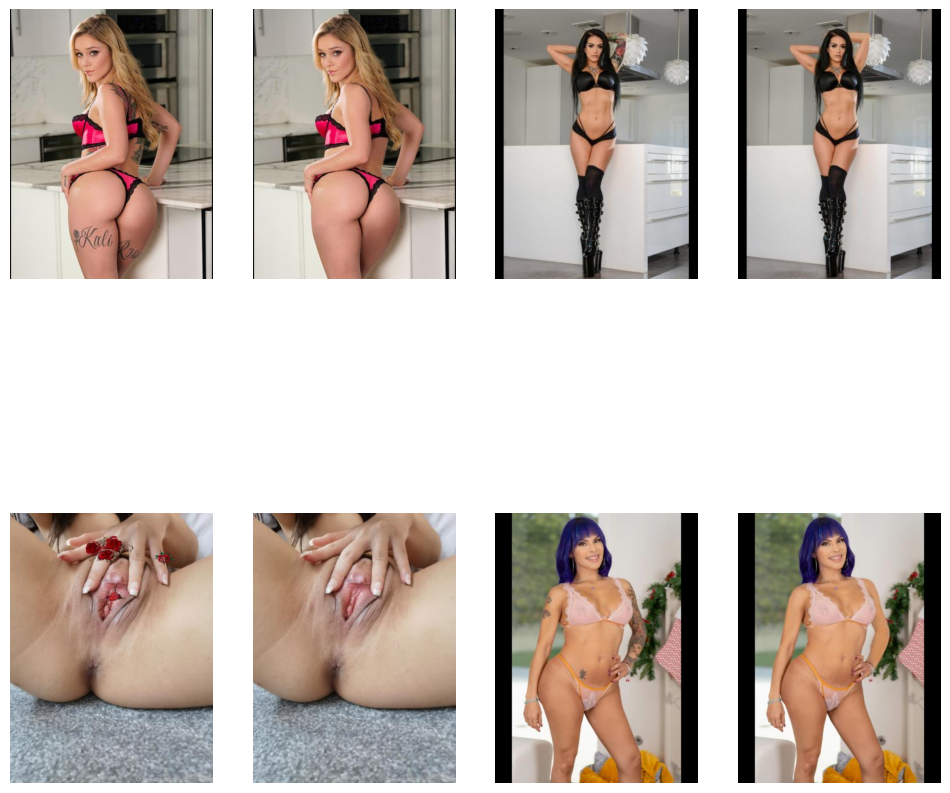

In [4]:
# Load our images
dls_gen = get_dls(batch_size, image_size) 
dls_gen.show_batch(max_n=4, figsize=(12,12))

In [5]:
# We'll want to get rid of any augmentation, drop_last, and shuffle from our training DataLoader:
dl = dls_gen.train.new(shuffle=False, drop_last=False, 
                       after_batch=[IntToFloatTensor, Normalize.from_stats(*imagenet_stats)])

In [6]:
# Get the predictions
preds, _ = learn.get_preds(dl=dl)

# Save the predictions

In [7]:
#create the directory if needed
path_deinked_gen.mkdir(exist_ok=True)

# Clean things up in case there was already stuff there
for f in path_deinked_gen.glob('*.jpg'):
    os.remove(f)

In [8]:
# get the names of the dataset items
names = dl.dataset.items

max_count = len(names)
f = IntProgress(min=0, max=max_count, description="Predictions: ") # instantiate the bar
display(f) # display the bar

# loop over and save everything
for i,pred in enumerate(preds):
    f.value += 1 # signal to increment the progress bar
    
    #print(f'Saving {names[i].name}')
    dec = dl.after_batch.decode((TensorImage(pred[None]),))[0][0]
    arr = dec.numpy().transpose(1,2,0).astype(np.uint8)
    Image.fromarray(arr).save(path_deinked_gen/names[i].name)

IntProgress(value=0, description='Predictions: ', max=172)